# Hexbin Chart

A hexbin chart is a scatter chart for when there are too many points to see. It tiles the plane with hexagons and colors each one by the number of points that fall in it, or by an aggregate of a value the points carry, so the density and the trends of thousands of points stay readable. This guide shows how to create hexbin charts with the [datachart.charts.HexbinChart](../../../references/charts/hexbinchart/#datachart.charts.HexbinChart) function, starting with the basics and building up to worked examples on illustrative data.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-hexbin-chart), which maps common tasks to the parameter or style attribute that does the job.

In [1]:
from datachart.charts import HexbinChart, ScatterChart

## Basics

The examples in this guide share one dataset: 8,000 apartment listings of a mid-sized city. The listings are illustrative, generated with a seeded random generator in the hidden cell below, but they follow the shape of real rental markets: floor areas cluster around 60 m² with a long tail of large apartments, the rent grows with the area at a rate set by the district, and overpriced apartments stay on the market longer. `listings` holds three columns: `x` is the floor area of each listing (m²), `y` its monthly rent (€), and `c` the number of days it stayed on the market. `points` holds the `x` and `y` columns alone, for the charts that count listings, and `district` holds the district of each listing (0 for the outskirts, 1 for midtown, 2 for the center).

In [2]:
import numpy as np

rng = np.random.RandomState(42)
N_LISTINGS = 8000
DISTRICTS = ["Outskirts", "Midtown", "Center"]
# the rent per m² of each district, in € per month
RATES = np.array([13.5, 16.0, 19.5])

district = rng.choice(3, size=N_LISTINGS, p=[0.5, 0.35, 0.15])
area = np.clip(rng.lognormal(np.log(60), 0.35, N_LISTINGS), 18, 220)
rent = np.clip(180 + RATES[district] * area + rng.normal(0, 120, N_LISTINGS), 300, None)
# listings priced above the city-wide rate stay on the market longer
premium = rent - (180 + 16.0 * area)
days = rng.gamma(2.0, np.clip(4 + 0.12 * area + 0.02 * premium, 2, None))

listings = {
    "x": np.round(area, 1).tolist(),
    "y": np.round(rent).tolist(),
    "c": np.round(days).tolist(),
}
points = {"x": listings["x"], "y": listings["y"]}

The data is a dictionary of columns, one value per listing in each column:

In [3]:
{key: values[:5] for key, values in listings.items()}

{'x': [83.9, 89.0, 30.3, 84.5, 45.2],
 'y': [1490.0, 1743.0, 625.0, 1449.0, 651.0],
 'c': [42.0, 56.0, 6.0, 5.0, 14.0]}

**The problem.** Plotted as a scatter chart, the 8,000 listings merge into one dark smear. The chart shows where the listings are, but not where most of them are: a region with ten listings and a region with three hundred look the same.

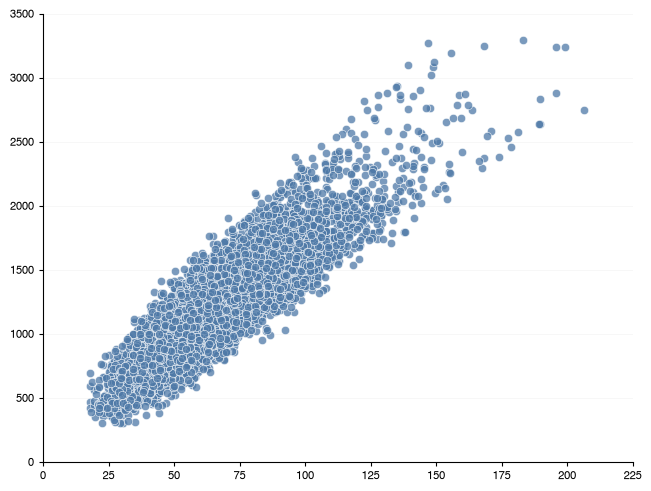

In [4]:
ScatterChart(
    # one record per listing
    data=[{"x": x, "y": y} for x, y in zip(points["x"], points["y"])],
).show()

**Basic example.** A hexbin chart of the same points needs only the `data` argument. Every hexagon is colored by the number of listings in it, and the colorbar maps the colors back to counts. The dense core around 50 m² and 1,000 € now stands out from the thin tail of large apartments. Every hexagon of the tiling is drawn, the empty ones in the lowest color, so a few large, expensive apartments stretch the tiling over a lot of empty plane; the [Minimum count](#minimum-count) section trims it.

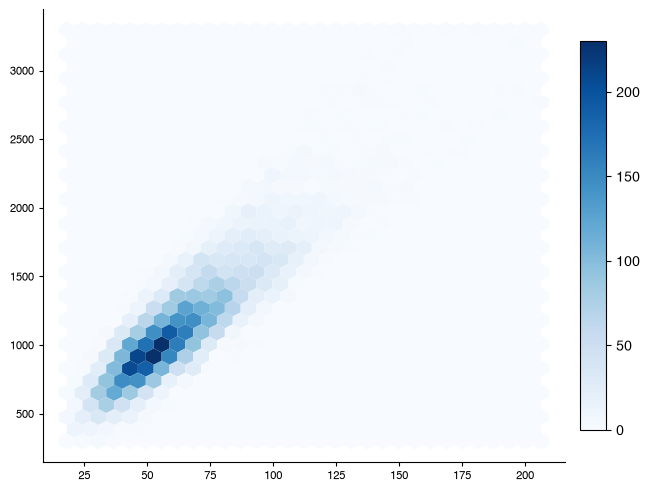

In [5]:
HexbinChart(
    # add the data to the chart
    data=points
).show()

## Customizing the Hexbin Chart

Every customization is either a keyword argument of `HexbinChart` or a `plot_hexbin_*` attribute of its `style` dictionary. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                 | See |
| :------------------------------------------ | :------------------------------------------------------------------ | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                         | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| fix the axis range or the ticks             | `xmin`, `xmax`, `ymin`, `ymax`, `xticks`, `yticks`                  | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| format or rotate the tick labels            | `xticks_format`, `yticks_format`, `xticklabels`, `xtickrotate`      | [Title, axis labels and ticks](#title-axis-labels-and-ticks) |
| resize the figure                           | `figsize`                                                           | [Figure size and grid](#figure-size-and-grid) |
| show the grid lines                         | `show_grid`                                                         | [Figure size and grid](#figure-size-and-grid) |
| caption, move, or hide the colorbar         | `colorbar`, `value_format`, `show_colorbars`                              | [Colorbar](#colorbar) |
| make the hexagons larger or smaller         | `gridsize`                                                          | [Grid size](#grid-size) |
| leave the sparse hexagons blank             | `mincnt`                                                            | [Minimum count](#minimum-count) |
| spread heavy-tailed counts over the colors  | `norm`, `vmin`, `vmax`                                              | [Normalization](#normalization) |
| color the hexagons by a value               | `c` in `data`, `reduce`                                             | [Aggregating a value](#aggregating-a-value) |
| change the colormap or draw hexagon edges   | `style={"plot_hexbin_cmap": ..., "plot_hexbin_edge_width": ...}`    | [Hexagon style](#hexagon-style) |
| highlight the densest hexagons              | `emphasis_rule`                                                     | [Emphasis](#emphasis) |
| mark a value or shade a range               | `vlines`, `hlines`, `dlines`, `vspans`, `hspans`                  | [Reference lines and bands](#reference-lines-and-bands) |
| put a note on the chart                     | `texts`                                                             | [Text annotations](#text-annotations) |
| draw each dataset in its own subplot        | `data` as a list, `subplots`, `max_cols`, `sharex`, `sharey`        | [Multiple Hexbin Charts](#multiple-hexbin-charts) |
| draw points or a trend over the hexagons    | `Panel`                                                             | [Composing with Panel](#composing-with-panel) |
| add a legend                                | `Panel` with `show_legend`, `legend`                                | [Composing with Panel](#composing-with-panel) |
| place the chart next to other charts        | `Grid`                                                              | [Composing with Grid](#composing-with-grid) |
| keep one unit equal on both axes            | `aspect_ratio`                                                      | [Aspect ratio](#aspect-ratio) |
| bin the points along a time axis            | `date` objects as `x`, `xticks_format`                              | [Datetime axis](#datetime-axis) |
| render the chart in another theme           | `config.set_theme`                                                  | [Themes](#themes) |
| save the chart to a file                    | `save_figure`                                                       | [Saving Figures](../../utility/saving/) guide |

The parameters that accept a constant, with the class in [datachart.constants](../../../references/constants/) that lists its values:

| Parameter | Constant |
| :-- | :-- |
| `reduce` | [`HEXBIN_REDUCE`](../../../references/constants/#datachart.constants.HEXBIN_REDUCE) |
| `xticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `figsize` | [`FIG_SIZE`](../../../references/constants/#datachart.constants.FIG_SIZE) |
| `legend={"location": ..., "alignment": ...}` | [`LEGEND_LOCATION`](../../../references/constants/#datachart.constants.LEGEND_LOCATION), [`LEGEND_ALIGN`](../../../references/constants/#datachart.constants.LEGEND_ALIGN) |
| `show_grid` | [`SHOW_GRID`](../../../references/constants/#datachart.constants.SHOW_GRID) |
| `aspect_ratio` | [`ASPECT_RATIO`](../../../references/constants/#datachart.constants.ASPECT_RATIO) |
| `scalex` | [`AXIS_SCALE`](../../../references/constants/#datachart.constants.AXIS_SCALE) |
| `scaley` | [`AXIS_SCALE`](../../../references/constants/#datachart.constants.AXIS_SCALE) |
| `norm` | [`COLOR_NORM`](../../../references/constants/#datachart.constants.COLOR_NORM) |
| `value_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT) |
| `yticks_format` | [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`DATE_FORMAT`](../../../references/constants/#datachart.constants.DATE_FORMAT) |
| `colorbar={"location": ..., "format": ..., "orientation": ...}` | [`COLORBAR_LOCATION`](../../../references/constants/#datachart.constants.COLORBAR_LOCATION), [`VALUE_FORMAT`](../../../references/constants/#datachart.constants.VALUE_FORMAT), [`ORIENTATION`](../../../references/constants/#datachart.constants.ORIENTATION) |

The full list of style attributes is in the [datachart.typings.HexbinStyleAttrs](../../../references/charts/hexbinchart/#datachart.typings.HexbinStyleAttrs) type; the full list of parameters is in the [datachart.charts.HexbinChart](../../../references/charts/hexbinchart/#datachart.charts.HexbinChart) reference.

### Title, axis labels and ticks

A hexbin chart shows two quantities at once, and without axis labels the reader cannot tell which is which; `title`, `xlabel` and `ylabel` say it. `xmin`, `xmax`, `ymin` and `ymax` fix the axis range, which here cuts off the thin tail of apartments above 160 m² so the dense part gets the room. `xticks` and `yticks` place the ticks, and `yticks_format` formats their labels with a [VALUE_FORMAT](../../../references/constants/#datachart.constants.VALUE_FORMAT) member or any `"{x:.1f}"` style string, so the rent axis reads in thousands with a separator. `xticklabels`, `xtickrotate` and their `y` counterparts replace or tilt the labels when they need it.

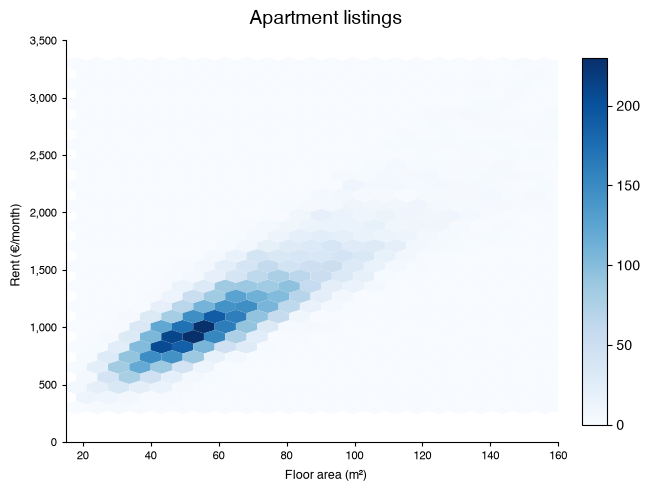

In [6]:
from datachart.constants import VALUE_FORMAT

HexbinChart(
    data=points,
    # add the title
    title="Apartment listings",
    # add the x and y axis labels
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    # focus on the apartments up to 160 m²
    xmin=15,
    xmax=160,
    ymin=0,
    ymax=3500,
    # one tick every 20 m², rents with a thousands separator
    xticks=[20, 40, 60, 80, 100, 120, 140, 160],
    yticks_format=VALUE_FORMAT.THOUSANDS,
).show()

### Figure size and grid

The default figure is nearly square, while a chart in a report usually spans the page width. `figsize` takes a `(width, height)` tuple in inches or one of the presets in [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE). The grid is off by default, because the hexagons would cover it; `show_grid` with a [SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) member draws it over the hexagons, which helps to read off the rent of the dense core.

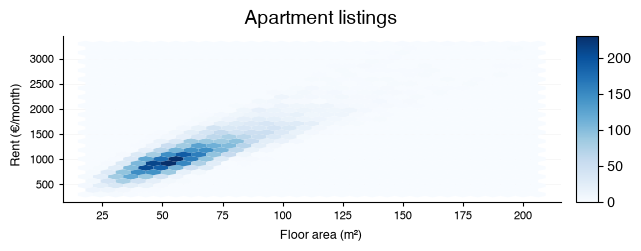

In [7]:
from datachart.constants import FIG_SIZE, SHOW_GRID

HexbinChart(
    data=points,
    title="Apartment listings",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    # a wide, short figure
    figsize=FIG_SIZE.FULL_SHORT,
    # grid lines along the rent axis
    show_grid=SHOW_GRID.Y,
).show()

### Colorbar

The colorbar is the legend of a hexbin chart: without a caption, the reader does not know that the colors count listings. `colorbar` takes a [ColorbarSettingAttrs](../../../references/typings/#datachart.typings.ColorbarSettingAttrs) dictionary: `label` captions the bar, `location` moves it to any edge with a [COLORBAR_LOCATION](../../../references/constants/#datachart.constants.COLORBAR_LOCATION) member, `ticks` places its ticks, and `format` formats their labels (the `value_format` parameter does the same when `format` is not set). A bar above a wide chart takes less width from the hexagons than one beside it. `show_colorbars=False` hides the bar, which suits a chart whose colors are explained elsewhere, as in the [Composing with Panel](#composing-with-panel) section.

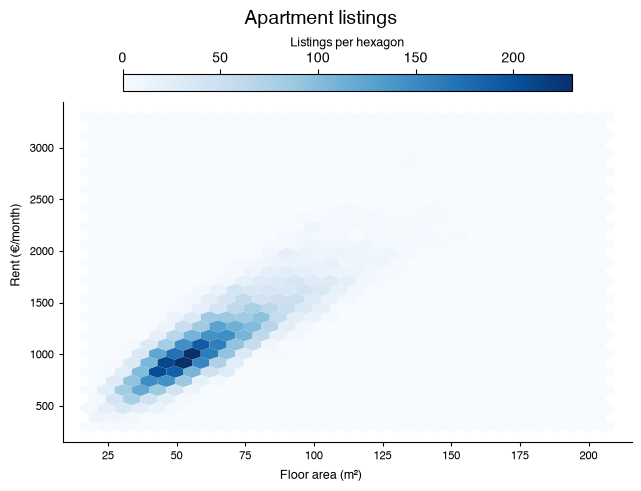

In [8]:
from datachart.constants import COLORBAR_LOCATION

HexbinChart(
    data=points,
    # a captioned colorbar above the chart, with integer ticks
    colorbar={
        "label": "Listings per hexagon",
        "location": COLORBAR_LOCATION.TOP,
        "ticks": [0, 50, 100, 150, 200],
        "format": VALUE_FORMAT.INTEGER,
    },
    title="Apartment listings",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Grid size

The hexagon size decides what the chart can show. Large hexagons hold many points each, so the colors are smooth but the shape is coarse; small hexagons resolve finer structure until each holds too few points to color reliably. `gridsize` sets the number of hexagons across the x-axis (30 by default, from the `plot_hexbin_gridsize` style attribute). With 12 hexagons the listings reduce to a rough diagonal; with 60 the core shows its finer shape, at the price of a noisier color.

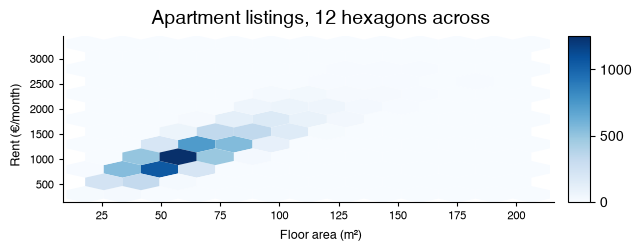

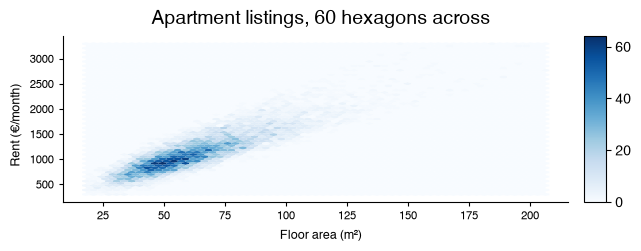

In [9]:
for gridsize in [12, 60]:
    HexbinChart(
        data=points,
        # the number of hexagons across the x-axis
        gridsize=gridsize,
        title=f"Apartment listings, {gridsize} hexagons across",
        xlabel="Floor area (m²)",
        ylabel="Rent (€/month)",
        figsize=FIG_SIZE.FULL_SHORT,
    ).show()

### Minimum count

Every hexagon of the tiling is drawn by default, so the tiling fills the whole bounding box of the points and empty plane looks like a region with few listings. `mincnt` leaves a hexagon blank unless at least that many points fall in it. `mincnt=1` draws only the hexagons that hold a listing, which shows the real outline of the data; a higher value also hides the hexagons with too few listings to trust.

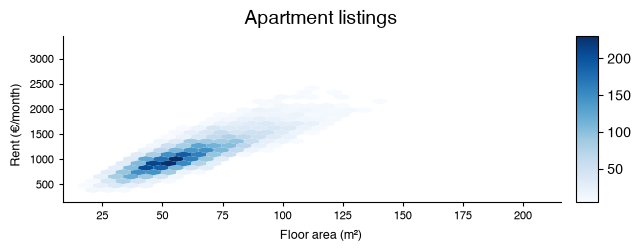

In [10]:
HexbinChart(
    data=points,
    # blank the hexagons with fewer than five listings
    mincnt=5,
    title="Apartment listings",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Normalization

Counts are heavy-tailed: a few hexagons in the core hold hundreds of listings while most hold a handful, so on a linear color scale nearly every hexagon draws in the palest shade. `norm` changes how the values map to colors with a [COLOR_NORM](../../../references/constants/#datachart.constants.COLOR_NORM) member; `COLOR_NORM.LOG` spreads the counts, so the tail of the distribution becomes visible. A log scale needs positive values, so pair it with `mincnt=1`. `vmin` and `vmax` pin the color range instead of taking it from the data, which keeps the colors of several charts comparable.

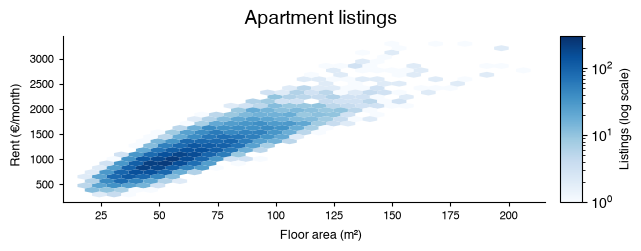

In [11]:
from datachart.constants import COLOR_NORM

HexbinChart(
    data=points,
    # log-scaled counts, so the sparse tail stays visible
    norm=COLOR_NORM.LOG,
    mincnt=1,
    # the color range, from one listing to 300
    vmin=1,
    vmax=300,
    colorbar={"label": "Listings (log scale)"},
    title="Apartment listings",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Aggregating a value

Density is one question; the other is how a third value varies across the plane. With a `c` column in the data, each hexagon shows an aggregate of the `c` values of its points instead of the count. `reduce` picks the aggregate with a [HEXBIN_REDUCE](../../../references/constants/#datachart.constants.HEXBIN_REDUCE) member: the mean by default, or the sum, median, minimum, or maximum. Only the hexagons holding a point are drawn, since an empty hexagon has nothing to aggregate, and an aggregate of one or two points is noisy, so `mincnt` hides those. Here `c` is the number of days a listing stayed on the market: the mean rises with the floor area and, at every area, with the rent.

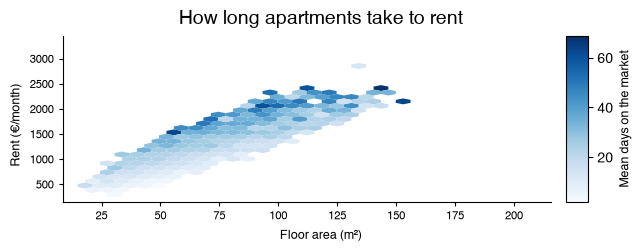

In [12]:
from datachart.constants import HEXBIN_REDUCE

HexbinChart(
    # x, y, and the per-point c to aggregate
    data=listings,
    # the mean of the c values in every hexagon
    reduce=HEXBIN_REDUCE.MEAN,
    # blank the hexagons with fewer than three listings
    mincnt=3,
    colorbar={"label": "Mean days on the market"},
    title="How long apartments take to rent",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

The other aggregates answer other questions. The median resists the few listings that stayed on the market for months; the maximum finds exactly those listings, which the mean smooths away:

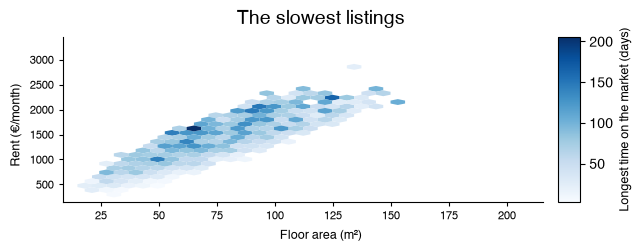

In [13]:
HexbinChart(
    data=listings,
    # the longest-listed apartment in every hexagon
    reduce=HEXBIN_REDUCE.MAX,
    mincnt=3,
    colorbar={"label": "Longest time on the market (days)"},
    title="The slowest listings",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Hexagon style

The colormap sets the tone of the chart: a sequential one for counts and other values that only grow, a diverging one for values with a meaningful middle. `plot_hexbin_cmap` takes a [COLORS](../../../references/constants/#datachart.constants.COLORS) member, a matplotlib colormap name, or a list of colors (the [Colormaps](../../styling/colormaps/) guide shows them all). Where neighboring hexagons have similar colors, they run together into a blur; `plot_hexbin_edge_width` and `plot_hexbin_edge_color` draw a thin edge that separates the tiles, and `plot_hexbin_alpha` makes the hexagons translucent. The attributes are listed in [HexbinStyleAttrs](../../../references/charts/hexbinchart/#datachart.typings.HexbinStyleAttrs).

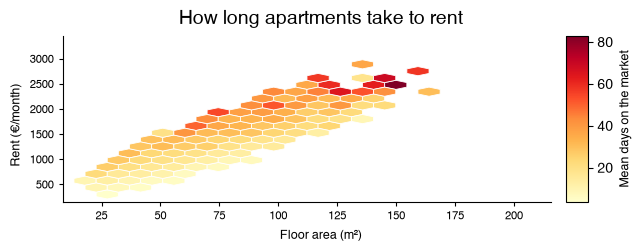

In [14]:
from datachart.constants import COLORS

HexbinChart(
    data=listings,
    reduce=HEXBIN_REDUCE.MEAN,
    mincnt=3,
    # a warm colormap and white edges between the hexagons
    style={
        "plot_hexbin_cmap": COLORS.YlOrRd,
        "plot_hexbin_edge_width": 0.6,
        "plot_hexbin_edge_color": "#FFFFFF",
    },
    gridsize=20,
    colorbar={"label": "Mean days on the market"},
    title="How long apartments take to rent",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Emphasis

Sometimes the question is not the whole distribution but a part of it: where most listings are, or which sizes and prices rent slowest. `emphasis_rule` outlines the hexagons whose value (the count, or the aggregate of `c`) matches a one-key rule and fades the rest: `{"top": n}` or `{"bottom": n}` by rank, `{"above": v}` or `{"below": v}` (strict), or `{"between": (lo, hi)}` (inclusive). A hexbin chart is one colormapped layer, so it does not take the per-series `emphasis` parameter of other charts. The [Highlighting](../../styling/highlighting/#emphasis-picked-by-a-rule) guide covers the rule on every chart. The chart below outlines the hexagons where the mean wait is above 40 days: the overpriced apartments.

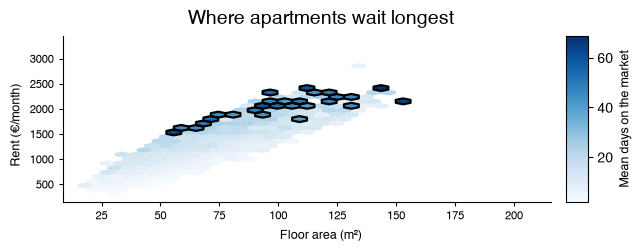

In [15]:
HexbinChart(
    data=listings,
    mincnt=3,
    # outline the hexagons with a mean wait above 40 days, fade the rest
    emphasis_rule={"above": 40},
    colorbar={"label": "Mean days on the market"},
    title="Where apartments wait longest",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Reference lines and bands

Reference lines and bands give the hexagons a frame to be read against. `vlines` and `hlines` draw a line at an x or y value, such as the median area and rent, which split the listings into four quadrants; `vspans` and `hspans` shade a range, such as a renter's budget. Each takes a dictionary or a list of them, with the position, an optional `label` and a `style`; the keys are listed in [VLineSettingAttrs](../../../references/typings/#datachart.typings.VLineSettingAttrs), [HLineSettingAttrs](../../../references/typings/#datachart.typings.HLineSettingAttrs), [VSpanSettingAttrs](../../../references/typings/#datachart.typings.VSpanSettingAttrs) and [HSpanSettingAttrs](../../../references/typings/#datachart.typings.HSpanSettingAttrs). A band needs at least one bound; an omitted bound runs to the edge of the axes. The chart below crosses the medians with dashed lines and shades a budget of 800 to 1,200 €, which shows how much of the market around the median a renter on that budget can reach.

`dlines` completes the trio. Where `vlines` fixes an x and `hlines` a y, a diagonal is fixed by a `slope` and an `intercept`, so it runs through the data space instead of across it; `dlines={}` on its own draws the parity line `y = x`. It spans the axes unless `xmin` and `xmax` clip it to a segment, and takes the same optional `label` and `style`; the keys are listed in [DLineSettingAttrs](../../../references/typings/#datachart.typings.DLineSettingAttrs). Both axes carry a measurement here, so a diagonal is a rate: the rent a square metre buys. The line is the median rate of the listings, and the hexagons above it are the listings that cost more per square metre than the market.

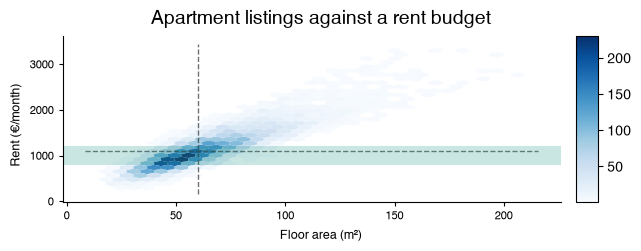

In [16]:
from datachart.constants import LINE_STYLE

# a translucent band drawn over the hexagons
BUDGET_STYLE = {"plot_hspan_color": "#2a9d8f", "plot_hspan_alpha": 0.25, "plot_hspan_zorder": 3}

HexbinChart(
    data=points,
    # the median area and rent, as dashed cross-hairs
    vlines={
        "x": float(np.median(points["x"])),
        "style": {"plot_vline_style": LINE_STYLE.DASHED, "plot_vline_color": "#333333"},
    },
    hlines={
        "y": float(np.median(points["y"])),
        "style": {"plot_hline_style": LINE_STYLE.DASHED, "plot_hline_color": "#333333"},
    },
    # a rent budget of 800 to 1,200 €
    hspans={"ymin": 800, "ymax": 1200, "style": BUDGET_STYLE},
    mincnt=1,
    title="Apartment listings against a rent budget",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

In [ ]:
rate = float(np.median(np.array(points["y"]) / np.array(points["x"])))

HexbinChart(
    data=points,
    # the median rent per square metre, through the origin
    dlines={
        "slope": rate,
        "intercept": 0,
        "label": f"median rate, {rate:.0f} €/m²",
        "style": {"plot_dline_color": "#1d3557", "plot_dline_style": LINE_STYLE.DASHED},
    },
    mincnt=1,
    title="Apartment listings against the median rent per square metre",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_legend=True,
).show()

A standalone hexbin chart has no legend, so a line's `label` only shows when the chart is composed in a `Panel` with a legend (see [Composing with Panel](#composing-with-panel)); on its own, a note from the next section names a line better.

### Text annotations

A note on the chart says what the reader should see. `texts` places text at a position in data coordinates (or in axes fractions with `"coords": "axes"`), and an optional `target` draws a connector to a point; the [Text Annotations](../../utility/annotations/) guide covers placement and styling. The note below points at the thin tail of large, expensive apartments, which is easy to overlook.

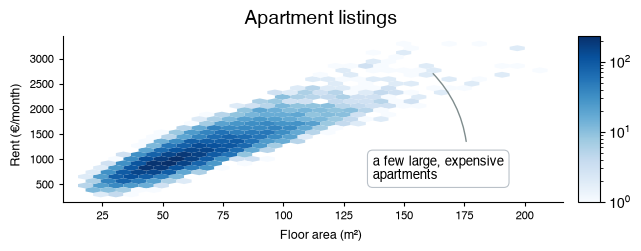

In [17]:
HexbinChart(
    data=points,
    mincnt=1,
    norm=COLOR_NORM.LOG,
    # a note in the empty corner, pointing at the tail
    texts={
        "text": "a few large, expensive\napartments",
        "x": 0.62,
        "y": 0.2,
        "coords": "axes",
        "target": (160, 2800),
    },
    title="Apartment listings",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

## Multiple Hexbin Charts

To compare several groups of points, pass a list of datasets to `data` and set `subplots=True`. Hexagons are opaque, so several datasets on one axes would cover each other; subplots keep each group visible. `subtitle` titles the subplots, while `title`, `xlabel` and `ylabel` stay global; `max_cols` limits the subplots per row, and `sharex` and `sharey` put the subplots on one axis range. The per-chart parameters (`subtitle`, `style`, `gridsize`, `reduce`, `mincnt`, `norm`, `vmin`, `vmax`, `value_format`, `colorbar`) take either one value for every chart or a list with one value per chart. Each subplot scales its colors to its own data, so the same `vmin` and `vmax` on every subplot are what makes the shades comparable. `points_by_district`, defined in a hidden cell, splits the listings by district: the center has fewer listings, and they sit higher on the rent axis.

In [18]:
by_district = [
    {key: [value for value, d in zip(listings[key], district) if d == i] for key in ("x", "y", "c")}
    for i in range(len(DISTRICTS))
]
points_by_district = [{"x": d["x"], "y": d["y"]} for d in by_district]

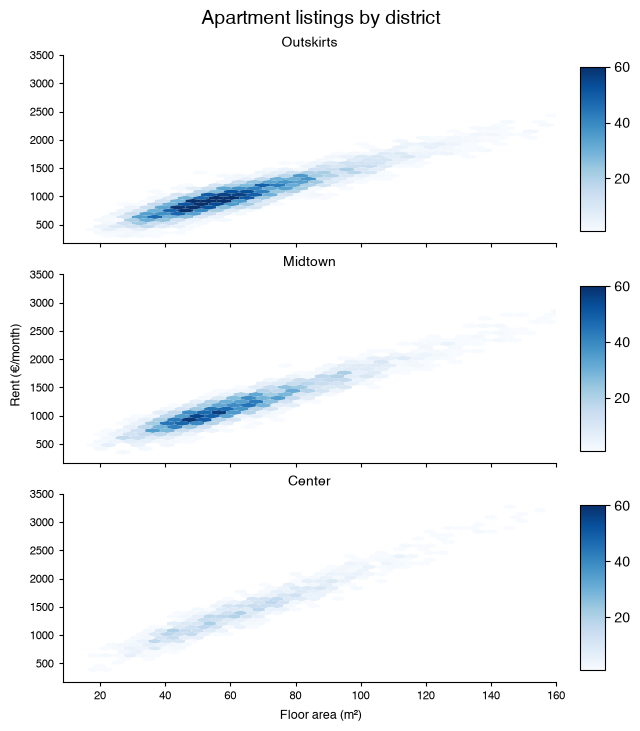

In [19]:
HexbinChart(
    # one dataset per district
    data=points_by_district,
    # one subplot title per chart
    subtitle=DISTRICTS,
    # one subplot per district, in one column
    subplots=True,
    max_cols=1,
    # the same axes for every district
    sharex=True,
    sharey=True,
    # the same color range for every district
    vmin=1,
    vmax=60,
    mincnt=1,
    gridsize=40,
    title="Apartment listings by district",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    xmax=160,
    ymax=3500,
    figsize=FIG_SIZE.FULL_TALL,
).show()

### Composing with Panel

A hexbin chart shows the crowd; a few points or a line on top of it show where individuals or a model sit in that crowd. [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) overlays figures on shared axes, and the [Panel](../../utility/panel/) guide covers it in full. Here a [ScatterChart](../../../references/charts/scatterchart/#datachart.charts.ScatterChart) of five listings a renter has shortlisted sits on the hexagons, which shows whether they are typical or overpriced; the shortlist spans a much smaller rent range than the market, so a `"y_axis"` on both figures pins them to one left axis instead of giving the shortlist a second one. The hexbin figure hides its colorbar, and the panel's `show_legend` and `legend` label the shortlist and the rent budget, which a standalone hexbin chart cannot do.

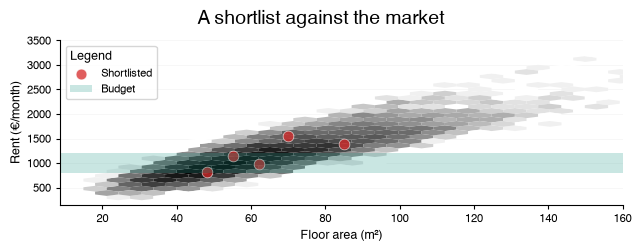

In [20]:
from datachart.constants import LEGEND_LOCATION
from datachart.utils import Panel

shortlist = [
    {"x": 48, "y": 820},
    {"x": 55, "y": 1150},
    {"x": 62, "y": 990},
    {"x": 70, "y": 1550},
    {"x": 85, "y": 1380},
]

Panel(
    [
        {
            "figure": HexbinChart(
                data=points,
                mincnt=1,
                norm=COLOR_NORM.LOG,
                # the budget band, labeled in the panel legend
                hspans={"ymin": 800, "ymax": 1200, "label": "Budget", "style": BUDGET_STYLE},
                style={"plot_hexbin_cmap": COLORS.Greys},
                show_colorbars=False,
            ),
            "y_axis": "left",
        },
        # the shortlisted listings, as points over the hexagons
        {
            "figure": ScatterChart(
                data=shortlist,
                subtitle="Shortlisted",
                style={"plot_scatter_size": 60, "plot_scatter_color": "#d62828"},
            ),
            # the same rent axis for both figures
            "y_axis": "left",
        },
    ],
    title="A shortlist against the market",
    xlabel="Floor area (m²)",
    ylabel_left="Rent (€/month)",
    xmax=160,
    ymax=3500,
    # a legend for the band and the points
    show_legend=True,
    legend={"location": LEGEND_LOCATION.UPPER_LEFT},
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Composing with Grid

A hexbin chart answers a question about two variables together, and a histogram of one of them often belongs beside it. [datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges figures in rows, each keeping its own axes; the [Grid](../../utility/grid/) guide covers layouts. The counts span the top row, and the days on the market and a histogram of the rents share the bottom one.

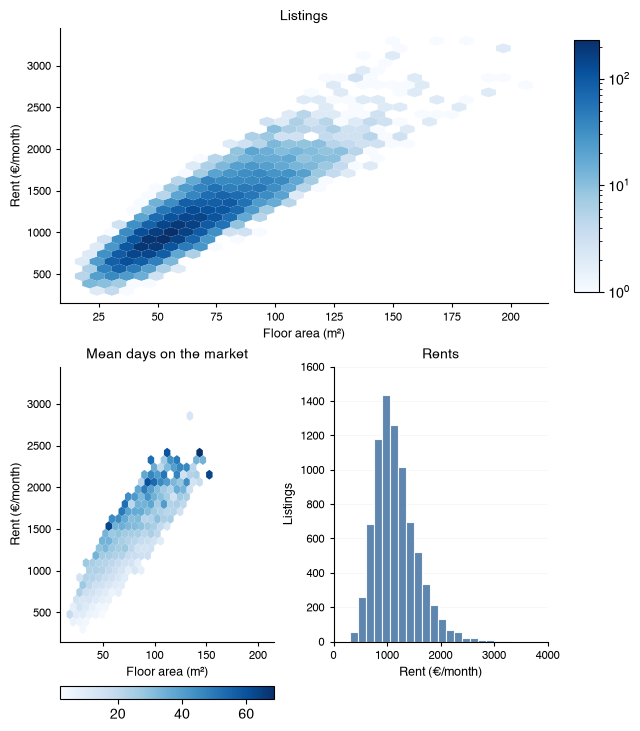

In [21]:
from datachart.charts import Histogram
from datachart.utils import Grid

Grid(
    [
        [
            HexbinChart(
                data=points,
                mincnt=1,
                norm=COLOR_NORM.LOG,
                title="Listings",
                xlabel="Floor area (m²)",
                ylabel="Rent (€/month)",
            )
        ],
        [
            HexbinChart(
                data=listings,
                mincnt=3,
                colorbar={"location": COLORBAR_LOCATION.BOTTOM},
                title="Mean days on the market",
                xlabel="Floor area (m²)",
                ylabel="Rent (€/month)",
            ),
            Histogram(
                data=[{"x": value} for value in listings["y"]],
                title="Rents",
                xlabel="Rent (€/month)",
                ylabel="Listings",
            ),
        ],
    ],
    figsize=FIG_SIZE.FULL_TALL,
).show()

## Additional Features

### Aspect ratio

By default the axes stretch to fill the figure, so one unit on the x-axis can be longer than one unit on the y-axis. For two variables in different units that is fine; for a map it distorts the city. `aspect_ratio` with [ASPECT_RATIO.EQUAL](../../../references/constants/#datachart.constants.ASPECT_RATIO) keeps one unit equal on both axes. `locations`, defined in a hidden cell, holds the illustrative position of every listing in kilometers east and north of the city center, with the listings bunched in the old town and two other neighborhoods.

In [22]:
# illustrative neighborhoods: (km east, km north), spread in km, share of listings
NEIGHBORHOODS = {
    "Old Town": ((0.0, 0.0), 0.9, 0.35),
    "University": ((3.5, 2.0), 0.7, 0.20),
    "Riverside": ((-3.0, -2.5), 1.1, 0.20),
}
loc_rng = np.random.RandomState(7)
east, north = [], []
for (cx, cy), spread, share in NEIGHBORHOODS.values():
    n = int(share * N_LISTINGS)
    east += (cx + loc_rng.normal(0, spread, n)).tolist()
    north += (cy + loc_rng.normal(0, spread, n)).tolist()
# the rest of the listings spread over the whole city
n_rest = N_LISTINGS - len(east)
east += loc_rng.normal(0, 3.5, n_rest).tolist()
north += loc_rng.normal(0, 3.0, n_rest).tolist()
locations = {"x": np.round(east, 2).tolist(), "y": np.round(north, 2).tolist()}

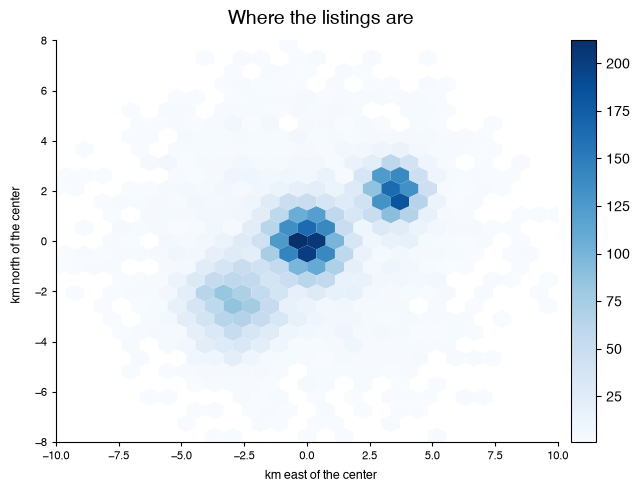

In [23]:
from datachart.constants import ASPECT_RATIO

HexbinChart(
    data=locations,
    # one kilometer is as long on both axes
    aspect_ratio=ASPECT_RATIO.EQUAL,
    mincnt=1,
    xmin=-10,
    xmax=10,
    ymin=-8,
    ymax=8,
    title="Where the listings are",
    xlabel="km east of the center",
    ylabel="km north of the center",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Datetime axis

Points spread over time are often too many for a scatter chart too: every listing of a year, every transaction of a quarter. An `x` column of real temporal objects (`datetime`, `date`, `numpy.datetime64` or a pandas `Timestamp`) bins the points along a time axis. `xticks_format` formats the ticks with a [DATE_FORMAT](../../../references/constants/#datachart.constants.DATE_FORMAT) member or any `strftime` pattern, and `xticks`, `xmin`, `xmax`, reference lines and bands take dates as well; date strings are not parsed and draw as categories. `rents_by_date`, defined in a hidden cell, dates every listing to the day it was posted in 2024, with an illustrative seasonal pattern: many listings go up in late summer, ahead of the academic year that starts on 1 October. The hexagons show the rush as a dense block of listings in September, at the usual rents.

In [24]:
from datetime import date, timedelta

date_rng = np.random.RandomState(11)
# 60% of the listings spread over the year, 40% around 5 September
day_of_year = np.where(
    date_rng.rand(N_LISTINGS) < 0.6,
    date_rng.randint(0, 366, N_LISTINGS),
    np.clip(date_rng.normal(248, 15, N_LISTINGS), 0, 365).astype(int),
)
rents_by_date = {
    "x": [date(2024, 1, 1) + timedelta(days=int(d)) for d in day_of_year],
    "y": listings["y"],
}

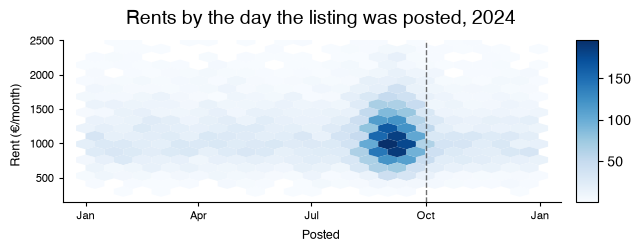

In [25]:
HexbinChart(
    data=rents_by_date,
    mincnt=1,
    gridsize=24,
    # one tick per quarter, labeled with the month name
    xticks=[date(2024, month, 1) for month in (1, 4, 7, 10)] + [date(2025, 1, 1)],
    xticks_format="%b",
    # the start of the academic year
    vlines={"x": date(2024, 10, 1), "style": {"plot_vline_style": LINE_STYLE.DASHED, "plot_vline_color": "#333333"}},
    ymax=2500,
    title="Rents by the day the listing was posted, 2024",
    xlabel="Posted",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

### Themes

A theme sets the colormap and the furniture of every chart at once; the [Theme Gallery](../../styling/theme-gallery/) shows each. Apply one with [datachart.config.Config.set_theme](../../../references/config/#datachart.config.Config.set_theme) and a [THEME](../../../references/constants/#datachart.constants.THEME) member, and reset the configuration afterwards so the following charts draw in the default. Style is read when the chart is built, so the figure keeps the theme after the reset.

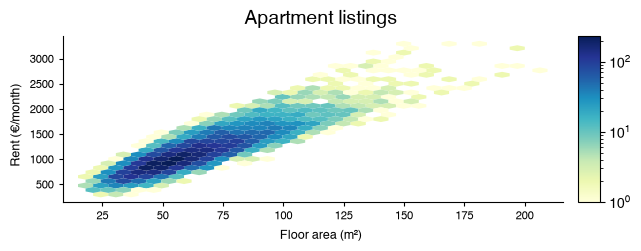

In [26]:
from datachart.config import config
from datachart.constants import THEME

config.set_theme(THEME.INK)

figure = HexbinChart(
    data=points,
    mincnt=1,
    norm=COLOR_NORM.LOG,
    title="Apartment listings",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    figsize=FIG_SIZE.FULL_SHORT,
)

config.reset_config()
figure.show()

## Real-World Examples

The examples below put the features above to work, each one answering a question about the rental market. The data is the illustrative, seeded listings of this guide, with the extra columns each example needs derived in a hidden cell.

### Example 1: Where Renting Is Cheap per Square Meter (Aggregation, a Diverging Colormap, and a Trend)

Renters compare apartments of different sizes by the rent per square meter. The hidden cell derives it for every listing as `per_m2`, the city-wide mean as `CITY_MEAN`, and a straight-line fit of the rent on the floor area as `fit`. Colored by the mean rent per square meter, the hexagons show what the counts hide: small apartments cost the most per square meter, and at every size the pricier listings sit above the fitted line. A diverging colormap centered on the city-wide mean by `vmin` and `vmax` splits the plane into the cheaper-than-average blues and the pricier reds, and a `Panel` lays the fitted rent over the hexagons, with a legend that labels it.

In [27]:
per_m2 = (np.array(listings["y"]) / np.array(listings["x"])).tolist()
CITY_MEAN = float(np.mean(per_m2))

slope, intercept = np.polyfit(listings["x"], listings["y"], 1)
FIT_X = np.linspace(20, 160, 30)
fit = [{"x": float(x), "y": float(slope * x + intercept)} for x in FIT_X]

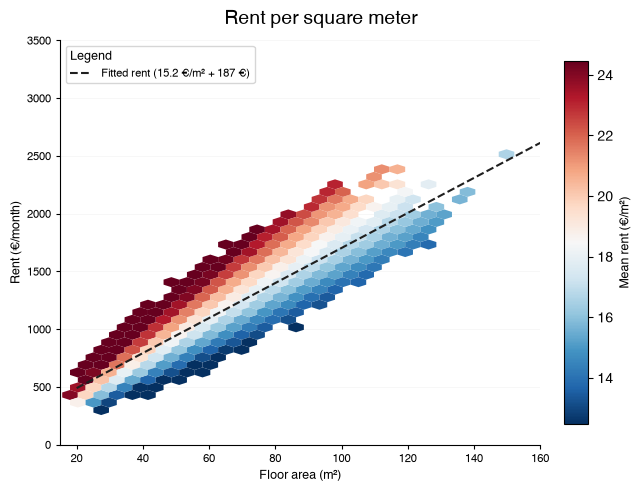

In [28]:
from datachart.charts import LineChart

Panel(
    [
        HexbinChart(
            data={"x": listings["x"], "y": listings["y"], "c": per_m2},
            reduce=HEXBIN_REDUCE.MEAN,
            mincnt=3,
            gridsize=40,
            # a diverging colormap centered on the city-wide mean;
            # the "_r" suffix reverses it, so the cheap side is blue
            style={"plot_hexbin_cmap": "RdBu_r"},
            vmin=CITY_MEAN - 6,
            vmax=CITY_MEAN + 6,
            colorbar={"label": "Mean rent (€/m²)", "format": VALUE_FORMAT.INTEGER},
        ),
        LineChart(
            data=fit,
            subtitle=f"Fitted rent ({slope:.1f} €/m² + {intercept:.0f} €)",
            style={"plot_line_color": "#1F1F1F", "plot_line_style": LINE_STYLE.DASHED},
        ),
    ],
    title="Rent per square meter",
    xlabel="Floor area (m²)",
    ylabel_left="Rent (€/month)",
    xmin=15,
    xmax=160,
    ymin=0,
    ymax=3500,
    show_legend=True,
    legend={"location": LEGEND_LOCATION.UPPER_LEFT},
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 2: Where the Listings Cluster (Equal Aspect, Log Counts, Emphasis, and Notes)

`locations` from the [Aspect ratio](#aspect-ratio) section places every listing on an illustrative map of the city, and a renter looking for a flat wants to know where the offer is. Log counts keep the thin suburbs visible next to the busy neighborhoods, the equal aspect ratio keeps the map undistorted, `emphasis_rule` outlines the 25 fullest hexagons, and a note names each neighborhood, placed in empty space at `LABEL_AT` and pointing at the center stored in `NEIGHBORHOODS`.

In [29]:
# where each neighborhood's note sits, in km east and north
LABEL_AT = {"Old Town": (-6.0, 5.0), "University": (6.5, 5.5), "Riverside": (-6.5, -6.0)}

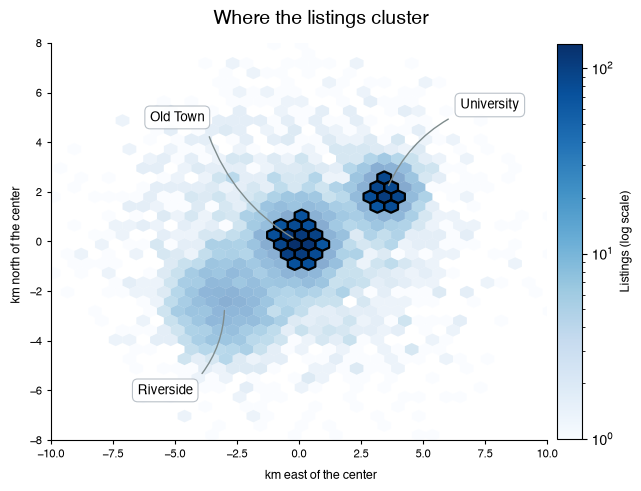

In [30]:
HexbinChart(
    data=locations,
    mincnt=1,
    gridsize=40,
    norm=COLOR_NORM.LOG,
    aspect_ratio=ASPECT_RATIO.EQUAL,
    # outline the 25 fullest hexagons
    emphasis_rule={"top": 25},
    # one note per neighborhood, pointing at its center
    texts=[
        {"text": name, "x": x, "y": y, "target": NEIGHBORHOODS[name][0]}
        for name, (x, y) in LABEL_AT.items()
    ],
    colorbar={"label": "Listings (log scale)"},
    xmin=-10,
    xmax=10,
    ymin=-8,
    ymax=8,
    title="Where the listings cluster",
    xlabel="km east of the center",
    ylabel="km north of the center",
    figsize=FIG_SIZE.FULL_MEDIUM,
).show()

### Example 3: Which Apartments Rent Fastest, by District (Log Counts, a Shared Color Range, and a Grid)

`by_district` from the [Multiple Hexbin Charts](#multiple-hexbin-charts) section splits the listings into the three districts, with the days on the market as `c`. Each row of the figure is one district. The left chart counts its listings on a log scale, so the sparse edges stay visible next to the dense core; the right chart shows the median days on the market, under one `vmin` and `vmax` for every district, so the same shade means the same wait everywhere. Read down the right column: the center's apartments are fewer, pricier, and slower to rent at every size, while the outskirts rent their small apartments fastest. A `Grid` lays out the six charts, and its `sharex`, `sharey`, `xlabel` and `ylabel` give them one frame.

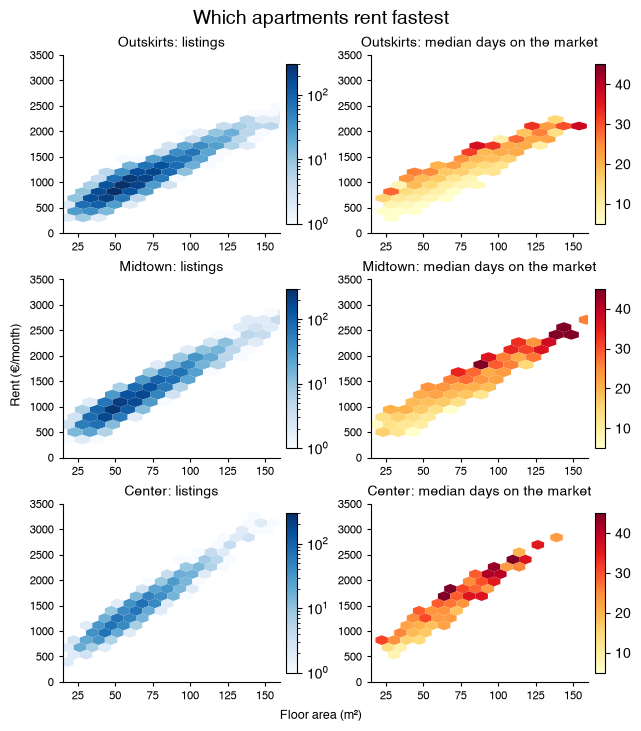

In [31]:
def district_row(name, data):
    # the listings and the median wait of one district, on the same axes
    frame = dict(gridsize=18, xmin=15, xmax=160, ymin=0, ymax=3500)
    count = HexbinChart(
        data={"x": data["x"], "y": data["y"]},
        norm=COLOR_NORM.LOG,
        mincnt=1,
        vmin=1,
        vmax=300,
        title=f"{name}: listings",
        **frame,
    )
    wait = HexbinChart(
        data=data,
        reduce=HEXBIN_REDUCE.MEDIAN,
        mincnt=3,
        # the same range in every district, so the shades compare
        vmin=5,
        vmax=45,
        style={"plot_hexbin_cmap": COLORS.YlOrRd},
        title=f"{name}: median days on the market",
        **frame,
    )
    return [count, wait]


Grid(
    [district_row(name, data) for name, data in zip(DISTRICTS, by_district)],
    title="Which apartments rent fastest",
    xlabel="Floor area (m²)",
    ylabel="Rent (€/month)",
    sharex=True,
    sharey=True,
    figsize=FIG_SIZE.FULL_TALL,
).show()